<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula05a_mlp_multiclasse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

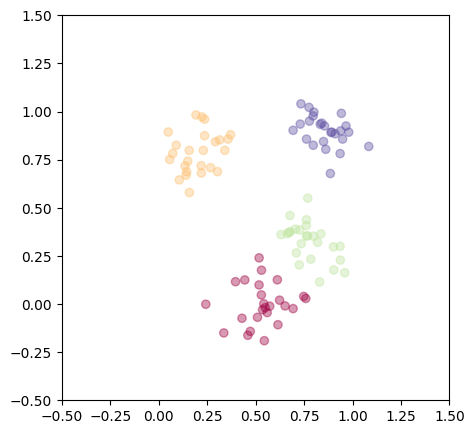

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def makeMulticlassDataset(n=100, n_classes=4):
  X, y = make_blobs(n_samples=n,
                    centers=n_classes,
                    center_box=(0,1),
                    cluster_std=0.1)
  return X, y

X, y = makeMulticlassDataset()
plotDataset(X, y)
plt.show()

In [17]:
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


Accuracy: 0.81


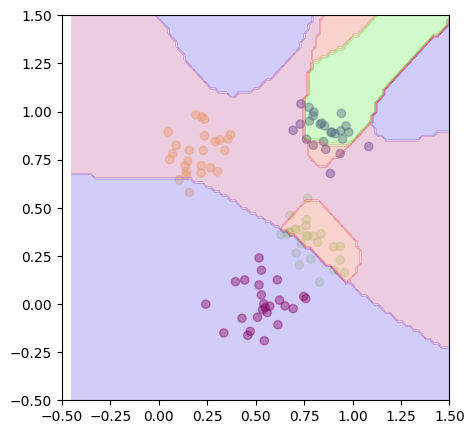

In [32]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class MultiLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10000, learning_rate=0.01,
               n_hidden=[2]):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = n_hidden
    self.activ_func = np.tanh

  def forward(self, X):
    self.A = []
    self.Z = []
    AUX = X.copy()
    for W in self.Ws:
      self.A.append(include_bias(AUX))
      self.Z.append(self.A[-1] @ W)
      AUX = self.activ_func(self.Z[-1])
    return AUX

  def backward(self, y, logits):
    grads = []
    output_delta = logits - y
    grads.insert(0, self.A[-1].T @ output_delta)
    for i in range(len(self.Ws)-1, 0, -1):
      tanh_grad = 1 - np.tanh(self.Z[i-1])**2
      input_delta = output_delta @ self.Ws[i][1:].T * tanh_grad
      grads.insert(0, self.A[i-1].T @ input_delta)
      output_delta = input_delta.copy()
    for i in range(len(self.Ws)):
      self.Ws[i] -= grads[i] * self.learning_rate

  def fit(self, X, y):
    self.lb = LabelBinarizer()
    y = self.lb.fit_transform(y)
    if len(y.shape) == 1:
      y = y.reshape(-1, 1)
    self.Ws = []
    previous_output = X.shape[1]
    for n in self.n_hidden:
      self.Ws.append(np.random.uniform(-1, 1, (previous_output+1, n)))
      previous_output = n
    self.Ws.append(np.random.uniform(-1, 1, (previous_output+1, y.shape[1])))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    ypred = sign(logits)
    return self.lb.inverse_transform(ypred)

model = MultiLayer(learning_rate=0.001, n_hidden=[50])
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
plotDataset(X, y)
plotPredictions(model, X)
plt.show()